# Step 1: Importing Required Libraries

In [16]:
%%capture
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split

import nltk
import string
import warnings
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

import tensorflow as tf
from tensorflow import keras
from keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

nltk.download('stopwords')
nltk.download('omw-1.4')
nltk.download('wordnet')
warnings.filterwarnings('ignore')

# Step 2: Loading the Dataset

In [17]:
# Splits produced by ml/data/split.py (stratified 70/15/15).
train_df = pd.read_csv('../data/processed/train.csv')
val_df = pd.read_csv('../data/processed/val.csv')
test_df = pd.read_csv('../data/processed/test.csv')

# Alias for downstream cells that reference `df` (shape / info / pie).
df = train_df

print(f"train: {train_df.shape}  val: {val_df.shape}  test: {test_df.shape}")
df.head()


train: (17347, 2)  val: (3718, 2)  test: (3718, 2)


,class,tweet
0,1,LMFAOOOOOO GAY AS FUCK RT @PubesOnFleeK: &#128...
1,1,RT @OGTREEZ: Steve found out you can't call Ta...
2,2,@SBPart01 @melodybrooke11 fuzzy dice might be ...
3,1,@Midnight_Snacka now fuck that stfu shit how a...
4,2,Shut up birds it's bed time.


In [18]:
df.shape

(17347, 2)

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17347 entries, 0 to 17346
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   class   17347 non-null  int64
 1   tweet   17347 non-null  str  
dtypes: int64(1), str(1)
memory usage: 1.7 MB


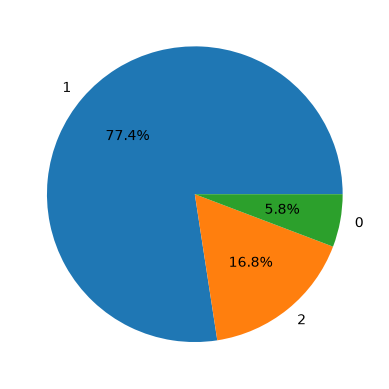

In [20]:
plt.pie(df['class'].value_counts().values,
        labels = df['class'].value_counts().index,
        autopct='%1.1f%%')
plt.show()

# Step 3: Splits Already Prepared

`train_df` / `val_df` / `test_df` were produced by `ml/data/split.py` (stratified 70/15/15, pinned seed).
Class proportions match the raw distribution across all three splits, so no additional balancing is applied at this stage.


In [21]:
# Splits are pre-made (see cell 4); alias balanced_df to train_df so
# downstream cells that reference `balanced_df` (preprocessing,
# tokenization) keep working without changes.
balanced_df = train_df.copy()


# Step 4: Text Preprocessing

In [22]:
punctuations_list = string.punctuation


def remove_punctuations(text):
    temp = str.maketrans('', '', punctuations_list)
    return text.translate(temp)


for split_df in (train_df, val_df, test_df):
    split_df['tweet'] = split_df['tweet'].str.lower()
    split_df['tweet'] = split_df['tweet'].apply(lambda x: remove_punctuations(x))

train_df.head()


,class,tweet
0,1,lmfaoooooo gay as fuck rt pubesonfleek 1285571...
1,1,rt ogtreez steve found out you cant call taiqu...
2,2,sbpart01 melodybrooke11 fuzzy dice might be th...
3,1,midnightsnacka now fuck that stfu shit how a b...
4,2,shut up birds its bed time


In [24]:
def preprocess_text(text):
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(word) for word in text.split() if word not in stop_words]
    return " ".join(words)


for split_df in (train_df, val_df, test_df):
    split_df['tweet'] = split_df['tweet'].apply(preprocess_text)


# Step 5: Tokenization and Padding

In [25]:
X_train = train_df['tweet']
Y_train = train_df['class']
X_val = val_df['tweet']
Y_val = val_df['class']

# One-hot encode the labels
Y_train = pd.get_dummies(Y_train)
Y_val = pd.get_dummies(Y_val)

# Tokenization
max_words = 5000
max_len = 100
tokenizer = Tokenizer(num_words=max_words, lower=True, split=' ')
tokenizer.fit_on_texts(X_train)

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)

# Pad sequences
X_train_padded = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_val_padded = pad_sequences(X_val_seq, maxlen=max_len, padding='post', truncating='post')


# Step 6: Build the Model

In [26]:
from tensorflow import keras
from tensorflow.keras import layers

max_words = 10000
max_len = 100 

model = keras.models.Sequential([
    layers.Embedding(input_dim=max_words, output_dim=32, input_length=max_len),
    layers.Bidirectional(layers.LSTM(16)),
    layers.Dense(512, activation='relu', kernel_regularizer='l1'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')  
])

model.build(input_shape=(None, max_len))

model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 32)             │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 346,755 (1.32 MB)

 Trainable params: 345,731 (1.32 MB)

 Non-trainable params: 1,024 (4.00 KB)

# Step 7: Training the Model

In [27]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

es = EarlyStopping(patience=3, monitor='val_accuracy', restore_best_weights=True)
lr = ReduceLROnPlateau(patience=2, monitor='val_loss', factor=0.5, verbose=0)

In [28]:
history = model.fit(X_train_padded, Y_train,
                    validation_data=(X_val_padded, Y_val),
                    epochs=50,
                    batch_size=32,
                    callbacks=[es, lr])

Epoch 1/50
543/543 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8613 - loss: 1.0521 - val_accuracy: 0.7867 - val_loss: 0.5497 - learning_rate: 0.0010
Epoch 2/50
543/543 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9020 - loss: 0.3545 - val_accuracy: 0.8876 - val_loss: 0.3901 - learning_rate: 0.0010
Epoch 3/50
543/543 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9119 - loss: 0.3139 - val_accuracy: 0.8857 - val_loss: 0.4190 - learning_rate: 0.0010
Epoch 4/50
543/543 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9223 - loss: 0.2765 - val_accuracy: 0.8857 - val_loss: 0.4342 - learning_rate: 0.0010
Epoch 5/50
543/543 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9383 - loss: 0.2063 - val_accuracy: 0.8854 - val_loss: 0.4533 - learning_rate: 5.0000e-04


# Step 8: Evaluating the Model

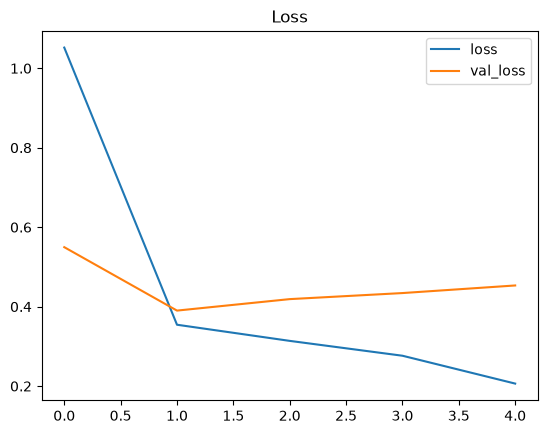

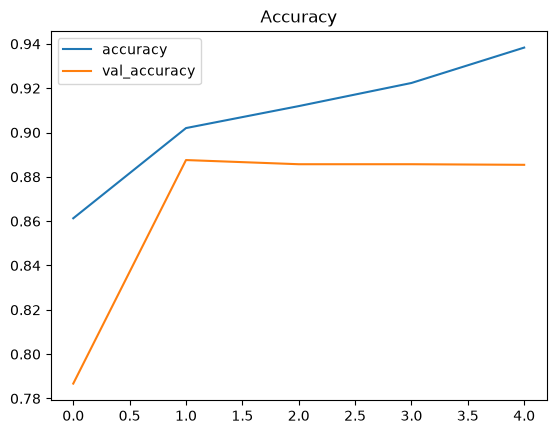

In [29]:
history_df = pd.DataFrame(history.history)

history_df[['loss', 'val_loss']].plot(title="Loss")

history_df[['accuracy', 'val_accuracy']].plot(title="Accuracy")
plt.show()

In [30]:
# Evaluate on the validation set
val_loss, val_acc = model.evaluate(X_val_padded, Y_val)
print(f"Validation Accuracy: {val_acc:.2f}")

# Evaluate on the held-out test set (never seen during training)
X_test_seq = tokenizer.texts_to_sequences(test_df['tweet'])
X_test_padded = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')
Y_test = pd.get_dummies(test_df['class'])
test_loss, test_acc = model.evaluate(X_test_padded, Y_test)
print(f"Test Accuracy: {test_acc:.2f}")


117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8876 - loss: 0.3901
Validation Accuracy: 0.89
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8892 - loss: 0.3870
Test Accuracy: 0.89
